# Fast.ai Unit 2 Project: Ashryver Painting Classifier V2
This is the updated second version of the Ashryver painting classifier model. It will have more painting data per artist and leverage the predictions of a smaller model to also output the predicted artistic era of a painting. Addressing the watermmark issues, however, is difficult and may not happen.

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from pathlib import Path
from fastai.vision.all import * # fastai image classification
!pip install -Uqq duckduckgo_search==5.3.1b1

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Define the dataset folder explicitly so the name is stable across cells
painting_data = Path('painting_data')
print('painting_data =', painting_data)
painting_data.mkdir(exist_ok=True, parents=True)

painting_data = painting_data


In [2]:
import time
from duckduckgo_search import DDGS
from fastcore.all import *

def search_images(keywords, max_images=200):
    with DDGS() as ddgs:
        results = list(ddgs.images(keywords, max_results=max_images))
        time.sleep(2)
        return [r['image'] for r in results]

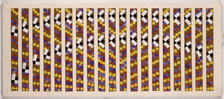

In [ ]:
from fastdownload import download_url
from fastai.vision.all import *

# See what kind of results we get for the Matisse The Bees situation
urls = search_images('matisse the bees', max_images=1)
urls[0] 
 
dest = 'matisse-bees-test.jpg'
download_url(urls[0], dest, show_progress=False)

im = Image.open(dest)
im.to_thumb(224,224) # show a preview of the image

# Just searching for 'matisse the bees' will indeed yield the accurate image

In [ ]:
# Full list of artists: 'monet', 'renoir', 'rivera', 'degas', 'morisot', 'cassatt', 'cezanne', 'van gogh', 'gauguin', 'manet', 'pissarro', 'seurat', 'toulouse-lautrec', 'whistler', 'turner', 'matisse', 'picasso', 'braque', 'mondrian', 'warhol', 

def download_artist_images(artist_names: list,
                           output_dir: Path = Path('painting_data'),
                           images_per_artist: int = 500,
                           URL: str = None):
    """Reusable function to download images of paintings efficiently.

    URL: optional query string or template for searches. If provided and containing
    '{artist_name}' it will be formatted per-artist, otherwise the literal string
    will be used for every artist. If omitted, a sensible default excluding
    common stock sites is used per-artist.
    """
    output_dir.mkdir(exist_ok=True, parents=True)

    for artist_name in artist_names:
        artist_dir = output_dir / artist_name
        artist_dir.mkdir(exist_ok=True, parents=True)

        # Determine query to use for this artist
        if URL is None:
            query = artist_name + " painting -site:gettyimages.com -site:alamy.com -site:123rf.com"
        else:
            try:
                query = URL.format(artist_name=artist_name)
            except Exception:
                # If formatting fails, fall back to using the URL string as-is
                query = URL

        urls = search_images(query, max_images=images_per_artist)

        download_images(artist_dir, urls=urls)
        print(f"Downloaded {len(urls)} images for {artist_name}")